# Exploratory Data Analysis (EDA) Notebook

## Week 3: Understand Your Data Through Visualization & Statistics

In this notebook, we'll explore patterns, relationships, and insights hidden in the cleaned data.

### Questions to Answer:
1. What are the basic statistics?
2. What does the data distribution look like?
3. Are there relationships between variables?
4. What are the unique values in categorical columns?
5. What insights can we extract?

---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded!")

Libraries loaded!


## Load the Clean Data

In [2]:
# TODO: Load your cleaned data
# df = pd.read_csv('../datasets/cleaned_data.csv')

# Or use the same sample data as before
df = pd.DataFrame({
    'ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Henry'],
    'Age': [25, 30, 28, 28, 35, 29, 26, 32],
    'Salary': [50000, 60000, 55000, 65000, 75000, 70000, 52000, 68000],
    'Department': ['Sales', 'IT', 'HR', 'Sales', 'IT', 'HR', 'IT', 'Sales'],
    'Years': [2, 5, 3, 4, 7, 6, 2, 4]
})

print(f"Data shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Data shape: (8, 6)

First few rows:


,ID,Name,Age,Salary,Department,Years
0,1,Alice,25,50000,Sales,2
1,2,Bob,30,60000,IT,5
2,3,Charlie,28,55000,HR,3
3,4,David,28,65000,Sales,4
4,5,Eve,35,75000,IT,7


## 1. Basic Statistics & Data Overview

In [3]:
# Basic information
print("Dataset Overview:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")

Dataset Overview:
Rows: 8, Columns: 6

Data types:
ID            int64
Name            str
Age           int64
Salary        int64
Department      str
Years         int64
dtype: object

Missing values: 0


In [4]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,ID,Age,Salary,Years
count,8.00000,8.000000,8.00000,8.000000
mean,4.50000,29.125000,61875.00000,4.125000
std,2.44949,3.226564,9062.28448,1.807722
min,1.00000,25.000000,50000.00000,2.000000
25%,2.75000,27.500000,54250.00000,2.750000
50%,4.50000,28.500000,62500.00000,4.000000
75%,6.25000,30.500000,68500.00000,5.250000
max,8.00000,35.000000,75000.00000,7.000000


## 2. Numerical Variable Analysis

### Age Distribution

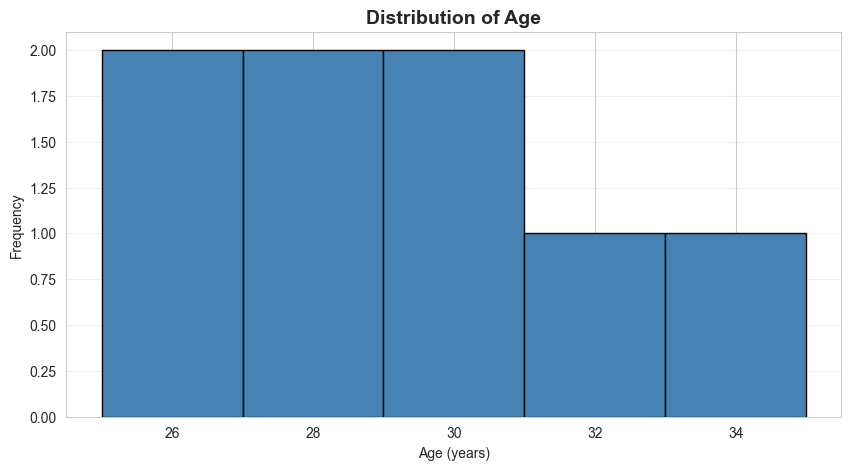

Age Statistics:
Mean: 29.1
Median: 28.5
Std Dev: 3.2
Min: 25, Max: 35


In [5]:
# Create a histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=5, edgecolor='black', color='steelblue')
plt.title('Distribution of Age', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Statistics
print("Age Statistics:")
print(f"Mean: {df['Age'].mean():.1f}")
print(f"Median: {df['Age'].median():.1f}")
print(f"Std Dev: {df['Age'].std():.1f}")
print(f"Min: {df['Age'].min()}, Max: {df['Age'].max()}")

### Salary Distribution

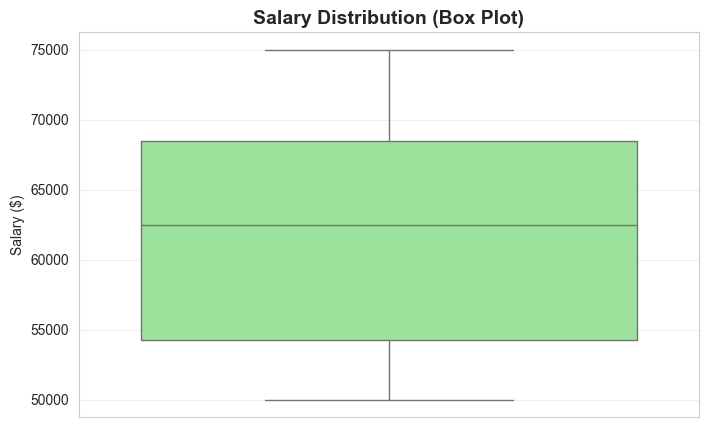

Salary Statistics:
Mean: $61,875
Median: $62,500
Range: $75,000 - $50,000


In [7]:
# Box plot for Salary
plt.figure(figsize=(8, 5))
sns.boxplot(df['Salary'], color='lightgreen')
plt.title('Salary Distribution (Box Plot)', fontsize=14, fontweight='bold')
plt.ylabel('Salary ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Salary Statistics:")
print(f"Mean: ${df['Salary'].mean():,.0f}")
print(f"Median: ${df['Salary'].median():,.0f}")
print(f"Range: ${df['Salary'].max():,.0f} - ${df['Salary'].min():,.0f}")

## 3. Categorical Variable Analysis

### Department Distribution

Employees by Department:
Department
Sales    3
IT       3
HR       2
Name: count, dtype: int64


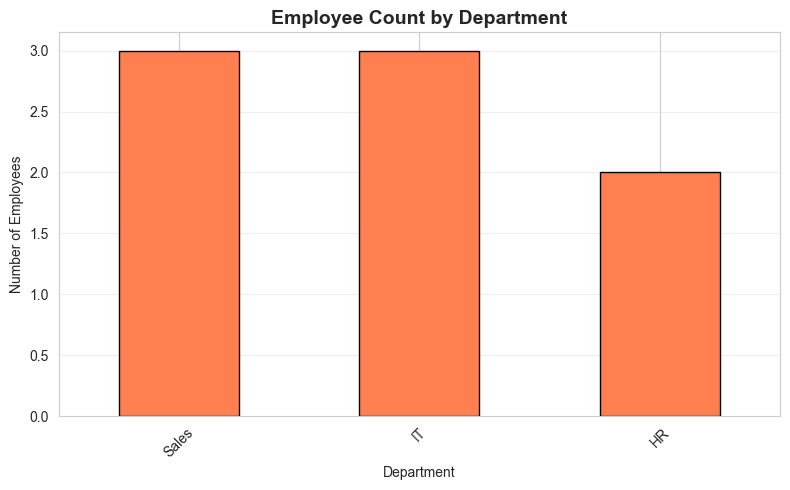

In [8]:
# Count of employees by department
dept_counts = df['Department'].value_counts()
print("Employees by Department:")
print(dept_counts)

# Bar chart
plt.figure(figsize=(8, 5))
dept_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Employee Count by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Relationships Between Variables

### Age vs Salary

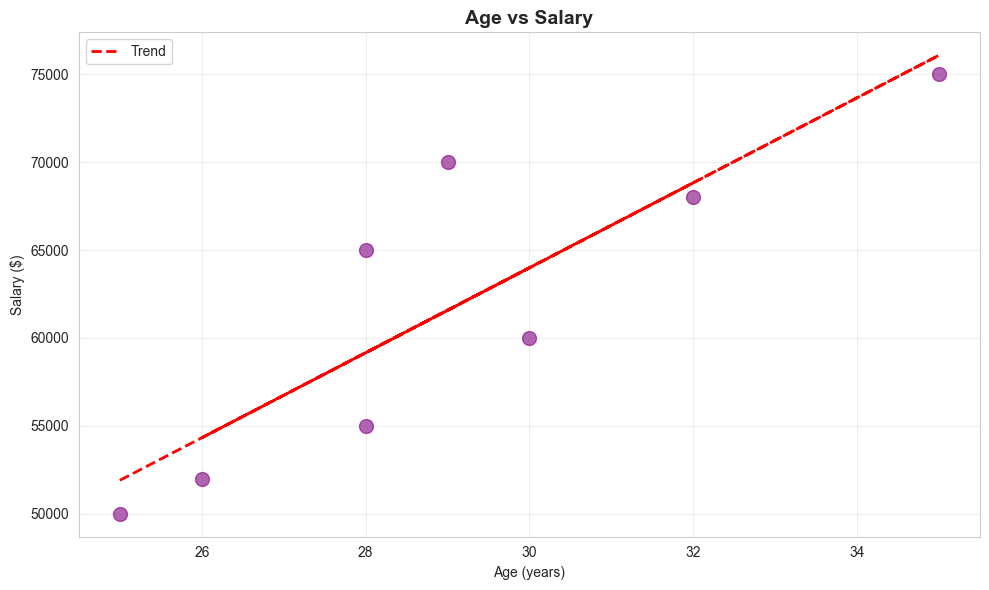


Correlation between Age and Salary: 0.860


In [9]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Salary'], s=100, alpha=0.6, color='purple')
plt.title('Age vs Salary', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Salary ($)')
plt.grid(alpha=0.3)

# Add a trend line
z = np.polyfit(df['Age'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(df['Age'], p(df['Age']), "r--", linewidth=2, label='Trend')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['Age'].corr(df['Salary'])
print(f"\nCorrelation between Age and Salary: {correlation:.3f}")

### Years of Experience vs Salary

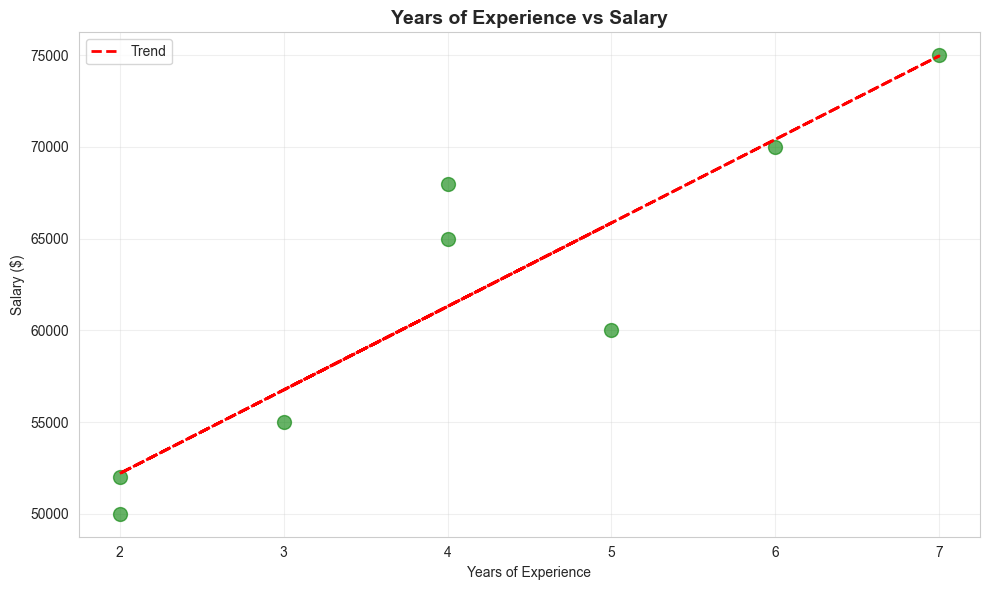

Correlation between Years and Salary: 0.908


In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Years'], df['Salary'], s=100, alpha=0.6, color='green')
plt.title('Years of Experience vs Salary', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.grid(alpha=0.3)

# Trend line
z = np.polyfit(df['Years'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(df['Years'], p(df['Years']), "r--", linewidth=2, label='Trend')
plt.legend()

plt.tight_layout()
plt.show()

correlation = df['Years'].corr(df['Salary'])
print(f"Correlation between Years and Salary: {correlation:.3f}")

### Salary by Department

C:\Users\Kolade\AppData\Local\Temp\ipykernel_12196\1025550495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Salary', palette='Set2', legend=False)


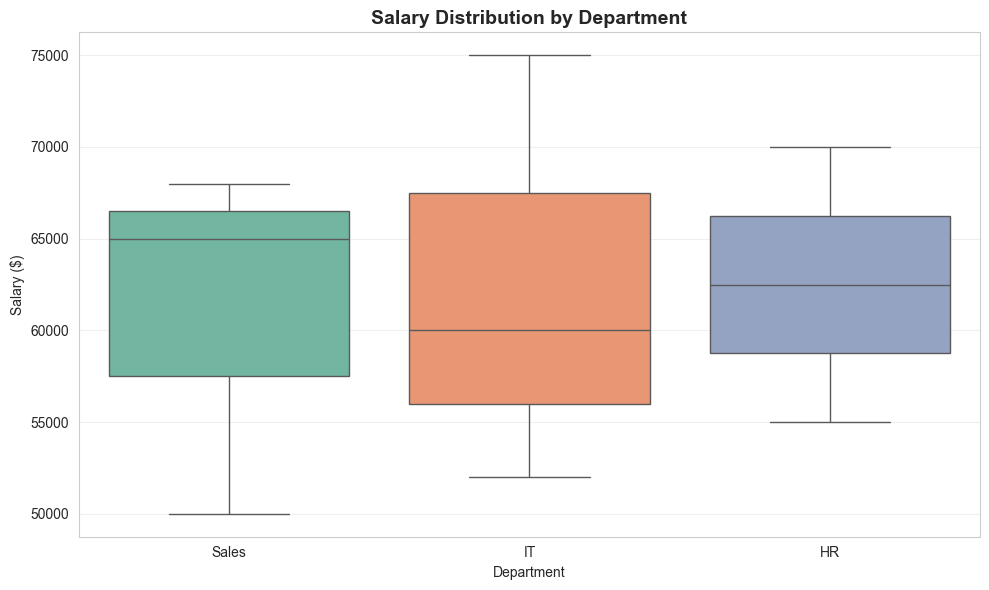

Average Salary by Department:
            Average Salary  Employee Count
Department                                
HR            62500.000000               2
IT            62333.333333               3
Sales         61000.000000               3


In [13]:
# Box plot comparing departments
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='Salary', palette='Set2', legend=False)
plt.title('Salary Distribution by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Salary ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Average salary by department
print("Average Salary by Department:")
avg_salary = df.groupby('Department')['Salary'].agg(['mean', 'count'])
avg_salary.columns = ['Average Salary', 'Employee Count']
print(avg_salary)

## 5. Correlation Analysis

Correlation Matrix:
              ID       Age    Salary     Years
ID      1.000000  0.352469  0.453709  0.177442
Age     0.352469  1.000000  0.860488  0.829678
Salary  0.453709  0.860488  1.000000  0.908004
Years   0.177442  0.829678  0.908004  1.000000


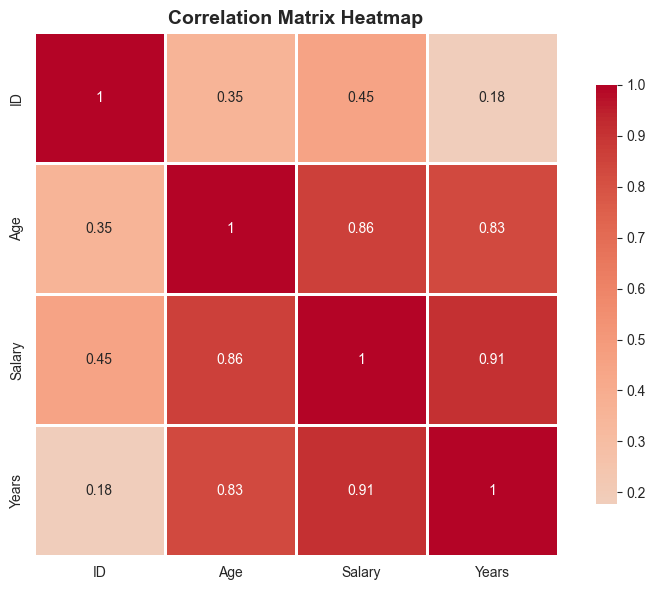

In [14]:
# Calculate correlation matrix
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Key Insights Summary

In [15]:
print("\n" + "="*60)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*60)

print(f"\n1. WORKFORCE COMPOSITION:")
print(f"   - Total employees: {len(df)}")
print(f"   - Most common department: {df['Department'].value_counts().index[0]} ({df['Department'].value_counts().values[0]} employees)")
print(f"   - Age range: {df['Age'].min()}-{df['Age'].max()} years (Avg: {df['Age'].mean():.1f})")

print(f"\n2. SALARY INSIGHTS:")
print(f"   - Average salary: ${df['Salary'].mean():,.0f}")
print(f"   - Salary range: ${df['Salary'].min():,.0f} - ${df['Salary'].max():,.0f}")
highest_dept = df.groupby('Department')['Salary'].mean().idxmax()
print(f"   - Highest paying department: {highest_dept}")

print(f"\n3. RELATIONSHIPS:")
exp_sal_corr = df['Years'].corr(df['Salary'])
age_sal_corr = df['Age'].corr(df['Salary'])
print(f"   - Years experience & Salary correlation: {exp_sal_corr:.3f} (Strong positive)")
print(f"   - Age & Salary correlation: {age_sal_corr:.3f}")

print(f"\n4. RECOMMENDATIONS:")
print(f"   - Experience is a strong predictor of salary")
print(f"   - Focus recruitment in IT department (highest avg salary)")
print(f"   - Consider salary equity analysis by department")

print("\n" + "="*60)


KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. WORKFORCE COMPOSITION:
   - Total employees: 8
   - Most common department: Sales (3 employees)
   - Age range: 25-35 years (Avg: 29.1)

2. SALARY INSIGHTS:
   - Average salary: $61,875
   - Salary range: $50,000 - $75,000
   - Highest paying department: HR

3. RELATIONSHIPS:
   - Years experience & Salary correlation: 0.908 (Strong positive)
   - Age & Salary correlation: 0.860

4. RECOMMENDATIONS:
   - Experience is a strong predictor of salary
   - Focus recruitment in IT department (highest avg salary)
   - Consider salary equity analysis by department



## Next Steps

1. ✅ Understand data distribution
2. ✅ Identify relationships
3. ✅ Draw conclusions
4. ➡️ **Next Week:** Use these insights for predictive modeling!